In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## Carregando Dados

In [2]:
df = pd.read_csv('vendas.csv')

In [3]:
df.shape

(66, 2)

In [4]:
df.head()

,mes,vendas
0,1,314.101
1,2,330.239
2,3,311.362
3,4,323.906
4,5,312.659


In [5]:
df.tail()

,mes,vendas
61,62,292.325
62,63,269.900
63,64,289.980
64,65,279.043
65,66,360.262


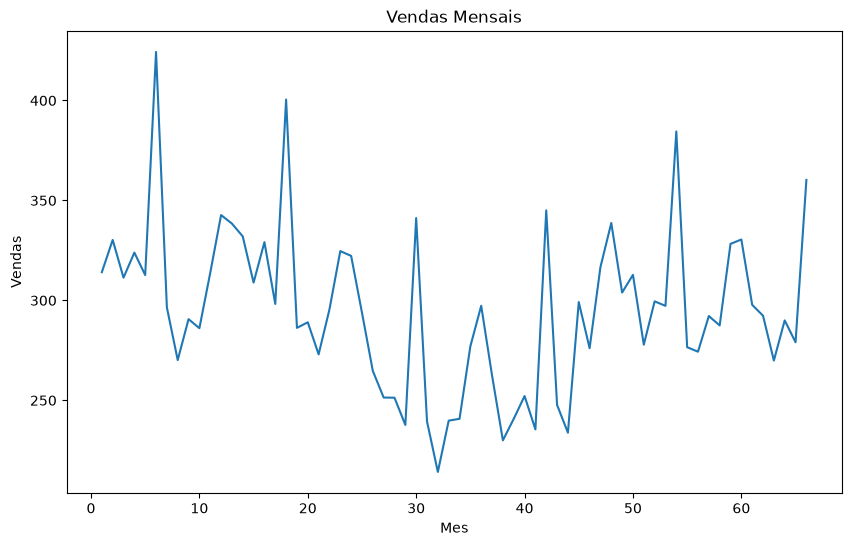

In [6]:
# Plotando graficos
plt.figure(figsize = (10,6))
plt.plot(df['mes'], df['vendas'])
plt.title('Vendas Mensais')
plt.xlabel('Mes')
plt.ylabel('Vendas')
plt.show()

## Analise Univariada

In [7]:
# Resumo estatistico
df.vendas.describe()

count     66.000000
mean     295.374853
std       40.968466
min      214.166000
25%      270.846000
50%      294.669500
75%      320.842000
max      424.281000
Name: vendas, dtype: float64

In [8]:
# Verificando valores ausentes
df.isnull().sum()

mes       0
vendas    0
dtype: int64

<Axes: ylabel='vendas'>

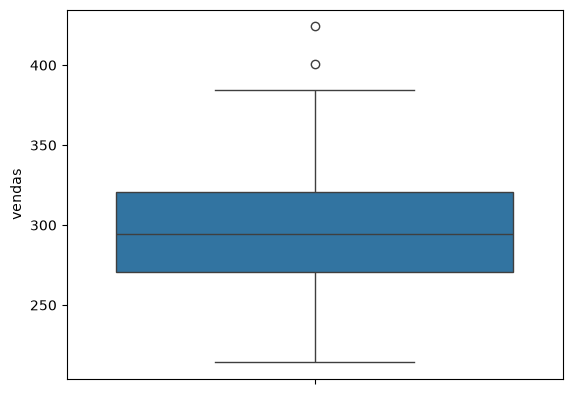

In [9]:
# Verificando outliers
sns.boxplot(df['vendas'])

## Decomposição da serie temporal

In [10]:
# Decomposição
decomposicao = seasonal_decompose(df['vendas'], model = 'additive', period=12)

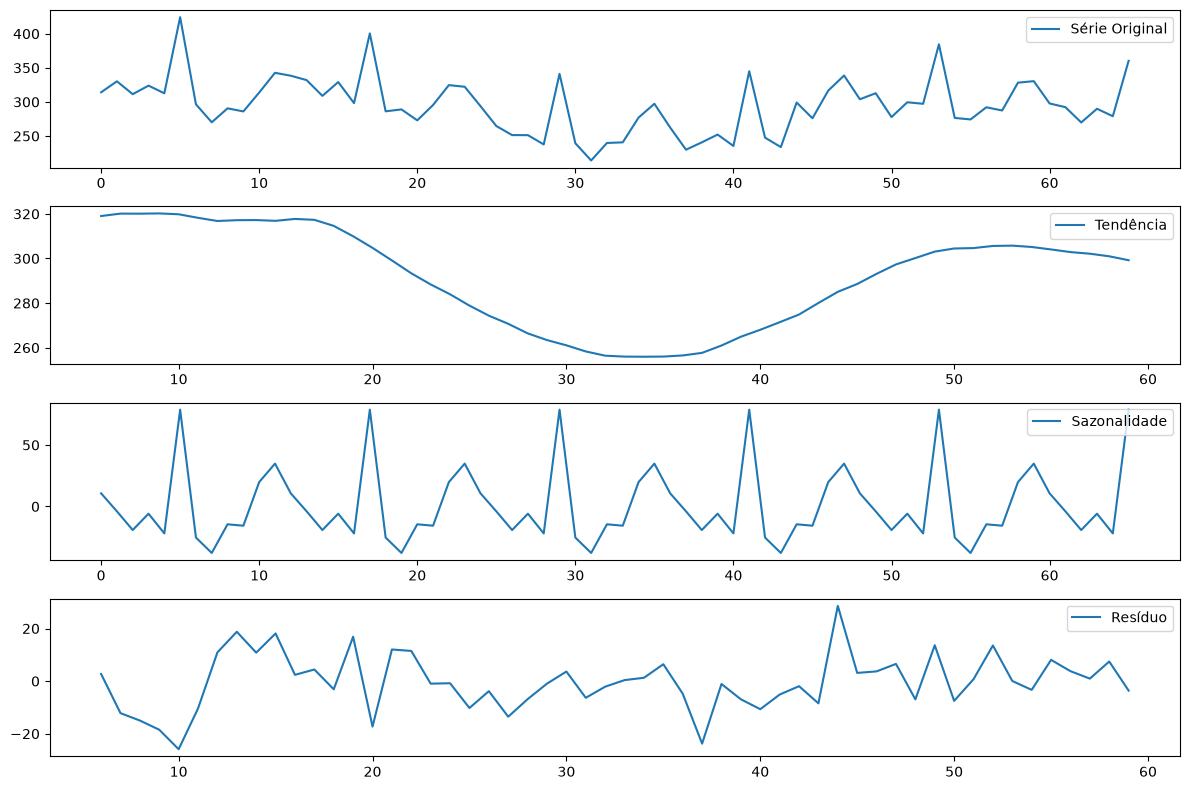

In [11]:
# Plotando os componentes
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df['vendas'], label = 'Série Original')
plt.legend(loc='best')

plt.subplot(412)
plt.plot(decomposicao.trend, label = 'Tendência')
plt.legend(loc='best')

plt.subplot(413)
plt.plot(decomposicao.seasonal, label = 'Sazonalidade')
plt.legend(loc='best')

plt.subplot(414)
plt.plot(decomposicao.resid, label = 'Resíduo')
plt.legend(loc='best')

plt.tight_layout()

## Testando a Estacionaridade

In [12]:
# Função para executar o teste dickfuller
def teste_estacionariedade(timeseries):

    print('Resultado do teste Dickey-Fuller:')

    dfteste = adfuller(timeseries, autolag = 'AIC')

    dfoutput = pd.Series(dfteste[0:4], index = ['Teste estatistic',
                                                'p-value',
                                                '#Lags Usados',
                                                'Numero de observações Usadas'])
    
    for key, value in dfteste[4].items():
        dfoutput['Valor Crítico (%s)' % key] = value
    
    print(dfoutput)

In [13]:
# Aplicandoma função
teste_estacionariedade(df['vendas'])

Resultado do teste Dickey-Fuller:


Teste estatistic                -0.997558
p-value                          0.754154
#Lags Usados                    11.000000
Numero de observações Usadas    54.000000
Valor Crítico (1%)              -3.557709
Valor Crítico (5%)              -2.916770
Valor Crítico (10%)             -2.596222
dtype: float64


In [14]:
# Trabalha em uma cópia para preservar o df original
df_diff = df.copy()
df_diff['vendas_diff'] = df_diff['vendas'].diff()

In [15]:
df_diff.head()

,mes,vendas,vendas_diff
0,1,314.101,NaN
1,2,330.239,16.138
2,3,311.362,-18.877
3,4,323.906,12.544
4,5,312.659,-11.247


In [16]:
# dropna apenas na cópia
df_diff.dropna(subset=['vendas_diff'], inplace=True)

In [17]:
df_diff.head()

,mes,vendas,vendas_diff
1,2,330.239,16.138
2,3,311.362,-18.877
3,4,323.906,12.544
4,5,312.659,-11.247
5,6,424.281,111.622


In [18]:
# Teste de Dickey-Fuller na 1ª diferença:
teste_estacionariedade(df_diff['vendas_diff'])

Resultado do teste Dickey-Fuller:
Teste estatistic                -1.588414
p-value                          0.489411
#Lags Usados                    11.000000
Numero de observações Usadas    53.000000
Valor Crítico (1%)              -3.560242
Valor Crítico (5%)              -2.917850
Valor Crítico (10%)             -2.596796
dtype: float64


### Segunda Diferenciação para Estacionaridade

In [19]:
# 1ª diferença ainda não é estacionária (p-value > 0.05)
# Aplica 2ª diferenciação
df_diff['vendas_diff2'] = df_diff['vendas_diff'].diff()
df_diff.dropna(subset=['vendas_diff2'], inplace=True)

In [20]:
# Teste de Dickey-Fuller na 2ª diferença:
teste_estacionariedade(df_diff['vendas_diff2'])

Resultado do teste Dickey-Fuller:
Teste estatistic                -5.258167
p-value                          0.000007
#Lags Usados                    11.000000
Numero de observações Usadas    52.000000
Valor Crítico (1%)              -3.562879
Valor Crítico (5%)              -2.918973
Valor Crítico (10%)             -2.597393
dtype: float64


### Modelo AR

In [21]:
# Modelo AR aplicado à série estacionária (2ª diferença)
modelo_AR = ARIMA(df_diff['vendas_diff2'], order=(1,0,0))
modelo_AR_treinado = modelo_AR.fit()
print(modelo_AR_treinado.summary())

                               SARIMAX Results                                
Dep. Variable:           vendas_diff2   No. Observations:                   64
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -355.020
Date:                Mon, 06 Jul 2026   AIC                            716.040
Time:                        09:53:56   BIC                            722.517
Sample:                             0   HQIC                           718.592
                                 - 64                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6754      5.438      0.124      0.901      -9.983      11.334
ar.L1         -0.6439      0.103     -6.231      0.000      -0.846      -0.441
sigma2      3820.4720    709.062      5.388      0.0

### Modelo MA

In [22]:
# Modelo MA
modelo_MA = ARIMA(df_diff['vendas_diff2'], order=(0,0,1))
modelo_MA_treinado = modelo_MA.fit()
print(modelo_MA_treinado.summary())

                               SARIMAX Results                                
Dep. Variable:           vendas_diff2   No. Observations:                   64
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -341.134
Date:                Mon, 06 Jul 2026   AIC                            688.267
Time:                        09:53:57   BIC                            694.744
Sample:                             0   HQIC                           690.819
                                 - 64                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1206      0.343      0.352      0.725      -0.551       0.793
ma.L1         -0.9997     24.772     -0.040      0.968     -49.553      47.553
sigma2      2339.0911    5.8e+04      0.040      0.9

### Modelo ARMA

In [23]:
# Modelo ARMA
modelo_ARMA = ARIMA(df_diff['vendas_diff2'], order=(1,0,1))
modelo_ARMA_treinado = modelo_ARMA.fit()
print(modelo_ARMA_treinado.summary())

                               SARIMAX Results                                
Dep. Variable:           vendas_diff2   No. Observations:                   64
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -334.915
Date:                Mon, 06 Jul 2026   AIC                            677.831
Time:                        09:53:59   BIC                            686.466
Sample:                             0   HQIC                           681.233
                                 - 64                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0954      0.225      0.425      0.671      -0.345       0.536
ar.L1         -0.4277      0.092     -4.655      0.000      -0.608      -0.248
ma.L1         -0.9999     49.610     -0.020      0.9

### Modelo ARIMA

In [24]:
# Modelo ARIMA com d=2 — reflete as 2 diferenciações necessárias
modelo_ARIMA = ARIMA(df['vendas'], order=(1,2,1))
modelo_ARIMA_treinado = modelo_ARIMA.fit()
print(modelo_ARIMA_treinado.summary())

                               SARIMAX Results                                
Dep. Variable:                 vendas   No. Observations:                   66
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -335.028
Date:                Mon, 06 Jul 2026   AIC                            676.056
Time:                        09:54:00   BIC                            682.532
Sample:                             0   HQIC                           678.607
                                 - 66                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4270      0.091     -4.699      0.000      -0.605      -0.249
ma.L1         -0.9993      5.803     -0.172      0.863     -12.373      10.374
sigma2      1906.4063    1.1e+04      0.174      0.8

### Modelo SARIMA

In [25]:
# Modelo SARIMA
# seasonal_order=(0,1,1,12): modelo airline — estável com poucas observações
# d=1 combinado com D=1 é suficiente para estacionaridade no contexto sazonal
modelo_SARIMA = SARIMAX(df['vendas'], order=(1,1,1), seasonal_order=(0,1,1,12))
modelo_SARIMA_treinado = modelo_SARIMA.fit(disp=False)
print(modelo_SARIMA_treinado.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             vendas   No. Observations:                   66
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -225.059
Date:                            Mon, 06 Jul 2026   AIC                            458.118
Time:                                    09:54:04   BIC                            465.999
Sample:                                         0   HQIC                           461.148
                                             - 66                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2743      0.452     -0.606      0.544      -1.161       0.612
ma.L1         -0.1158      0.433   

## Teste Ljung BOX para Modelo Sarima

In [26]:
residuos = modelo_SARIMA_treinado.resid

In [27]:
resultado_teste = acorr_ljungbox(residuos, lags=[6])

In [28]:
p_valores = resultado_teste
p_valores.head()

,lb_stat,lb_pvalue
6,5.071782,0.53464


### Forecast

In [29]:
# Fazendo a previsao para os proximos 6 meses
previsao_6meses = modelo_SARIMA_treinado.get_forecast(steps=6)

In [30]:
# Média
previsao_media = previsao_6meses.predicted_mean

In [31]:
previsao_media

66    258.791535
67    243.708015
68    267.266809
69    265.153002
70    300.123903
71    314.673236
Name: predicted_mean, dtype: float64

In [32]:
# Intervalo de Confiança
conf_int = previsao_6meses.conf_int()

In [33]:
conf_int

,lower vendas,upper vendas
66,228.756892,288.826178
67,208.527029,278.889000
68,226.019136,308.514482
69,219.024224,311.281781
70,249.484117,350.763689
71,259.919259,369.427213


In [34]:
print('Previsão para os próximos 6 meses:', previsao_media)

Previsão para os próximos 6 meses: 66    258.791535
67    243.708015
68    267.266809
69    265.153002
70    300.123903
71    314.673236
Name: predicted_mean, dtype: float64


In [35]:
print('Intervalo de confiança', conf_int)

Intervalo de confiança     lower vendas  upper vendas
66    228.756892    288.826178
67    208.527029    278.889000
68    226.019136    308.514482
69    219.024224    311.281781
70    249.484117    350.763689
71    259.919259    369.427213


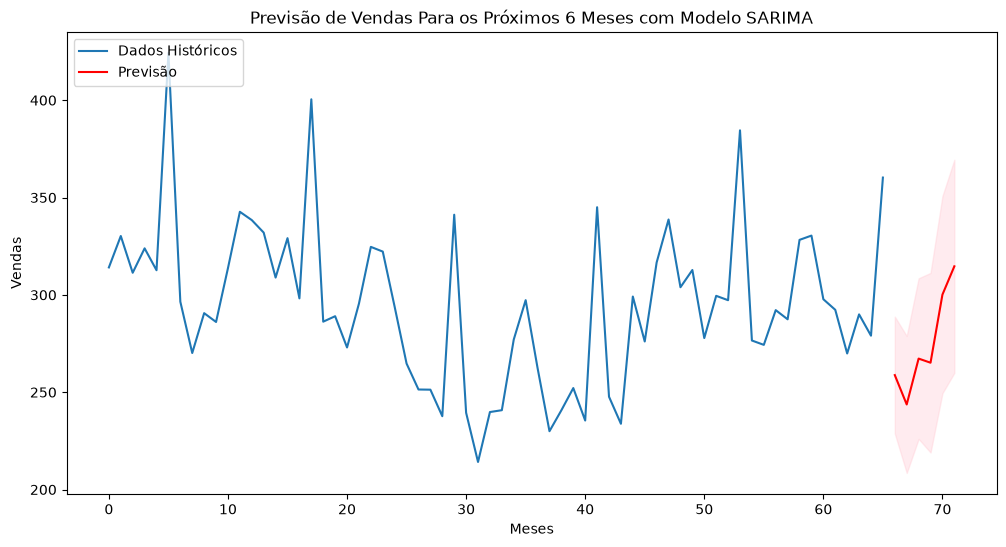

In [36]:
# Plotando os dados históricos
plt.figure(figsize = (12, 6))
plt.plot(df['vendas'], label = 'Dados Históricos')

# Plotando as previsões
eixo_x_futuro = np.arange(len(df['vendas']), len(df['vendas']) + 6)
plt.plot(eixo_x_futuro, previsao_media, label = 'Previsão', color = 'red')

# Plotando os intervalos de confiança
plt.fill_between(eixo_x_futuro, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color = 'pink', alpha = 0.3)

# Labels
plt.title('Previsão de Vendas Para os Próximos 6 Meses com Modelo SARIMA')
plt.xlabel('Meses')
plt.ylabel('Vendas')
plt.legend(loc='upper left')
plt.show()